# Churn Prediction (Retention Analysis)

Goal: Identify customers at risk of disengaging.

In [1]:

import os, glob
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve


In [2]:

DATA_DIR = "../data"

def load_data():
    def find(p):
        return glob.glob(os.path.join(DATA_DIR, f"*{p}*"))[0]

    tx = pd.read_csv(find("transaction"))
    hh = pd.read_csv(find("household"))

    tx.columns = tx.columns.str.lower()
    hh.columns = hh.columns.str.lower()

    return tx, hh

transactions, households = load_data()


In [3]:
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.replace("\n", "")
        .str.replace("\t", "")
        .str.strip()              # removes leading/trailing spaces
        .str.lower()
        .str.replace(" ", "_")    # converts internal spaces
    )
    return df

transactions = clean_columns(transactions).rename(columns={
    "purchase_": "purchase_date"
})

households = clean_columns(households).rename(columns={
    "l": "loyalty_flag"
})


print(transactions.columns.tolist())
print(households.columns.tolist())


['basket_num', 'hshd_num', 'purchase_date', 'product_num', 'spend', 'units', 'store_r', 'week_num', 'year']
['hshd_num', 'loyalty_flag', 'age_range', 'marital', 'income_range', 'homeowner', 'hshd_composition', 'hh_size', 'children']


In [4]:
def build_features(tx):
    tx = clean_columns(tx)
    
    cutoff = tx["week_num"].max() - 8
    
    tx_past = tx[tx["week_num"] <= cutoff]
    tx_future = tx[tx["week_num"] > cutoff]
    
    grouped = tx_past.groupby("hshd_num")
    
    last_week = grouped["week_num"].max()
    max_week = tx_past["week_num"].max()
    
    feat = pd.DataFrame({
        "recency": max_week - last_week,
        "frequency": grouped["basket_num"].nunique(),
        "monetary": grouped["spend"].sum()
    })
    
    # churn = no activity in future window
    active_future = tx_future["hshd_num"].unique()
    feat["churned"] = (~feat.index.isin(active_future)).astype(int)
    
    return feat.reset_index()

feat = build_features(transactions)
feat.head()

,hshd_num,recency,frequency,monetary,churned
0,10,0,136,8148.20,0
1,29,3,2,19.95,1
2,53,0,152,5008.43,0
3,54,0,205,6441.56,0
4,60,0,501,25631.74,0


In [5]:
# %%
corr = feat.corr(numeric_only=True)["churned"].sort_values()
print(corr)

monetary    -0.490895
frequency   -0.446376
hshd_num    -0.018268
recency      0.726219
churned      1.000000
Name: churned, dtype: float64


In [14]:
# %%
X = feat[["recency", "frequency", "monetary"]]
y = feat["churned"]

Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

scaler = StandardScaler()
Xtr_scaled = scaler.fit_transform(Xtr)
Xte_scaled = scaler.transform(Xte)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(Xtr_scaled, ytr)

probs = model.predict_proba(Xte_scaled)[:, 1]

In [15]:
# %%
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient")

print(coef_df)

     feature  coefficient
1  frequency    -2.703308
2   monetary    -2.696135
0    recency     0.747697


In [16]:
# %%
X_all = scaler.transform(feat[["recency", "frequency", "monetary"]])
feat["churn_prob"] = model.predict_proba(X_all)[:, 1]

feat.sort_values("churn_prob", ascending=False).head(10)

,hshd_num,recency,frequency,monetary,churned,churn_prob
356,4570,39,1,6.98,1,0.995814
241,2997,39,2,56.41,1,0.995650
156,1963,39,4,27.43,1,0.995565
55,780,34,1,1.99,1,0.992900
90,1234,31,1,26.44,1,0.990139
31,455,30,1,2.49,1,0.989158
132,1660,28,1,3.98,0,0.986604
235,2921,28,1,16.97,1,0.986526
372,4753,28,6,223.18,1,0.983985
125,1573,26,2,82.51,0,0.982602


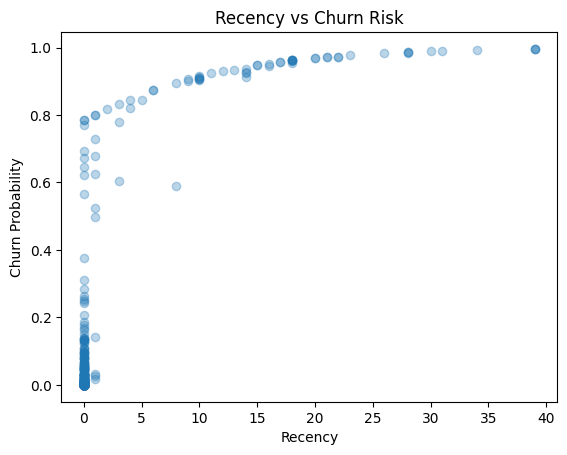

In [ ]:
plt.figure()
plt.scatter(feat["recency"], feat["churn_prob"], alpha=0.3)
plt.xlabel("Recency")
plt.ylabel("Churn Probability")
plt.title("Recency vs Churn Risk")
plt.show()

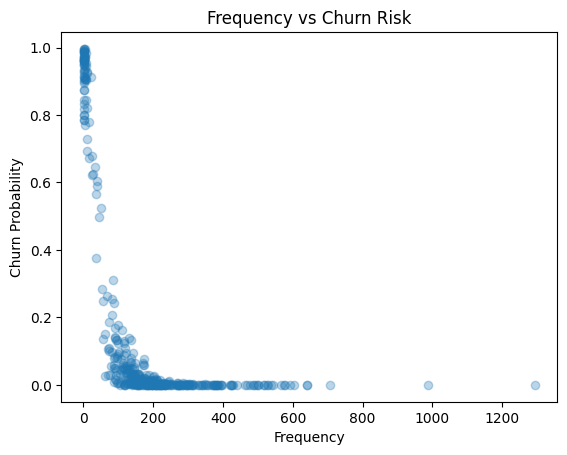

In [22]:
plt.figure()
plt.scatter(feat["frequency"], feat["churn_prob"], alpha=0.3)
plt.xlabel("Frequency")
plt.ylabel("Churn Probability")
plt.title("Frequency vs Churn Risk")
plt.show()

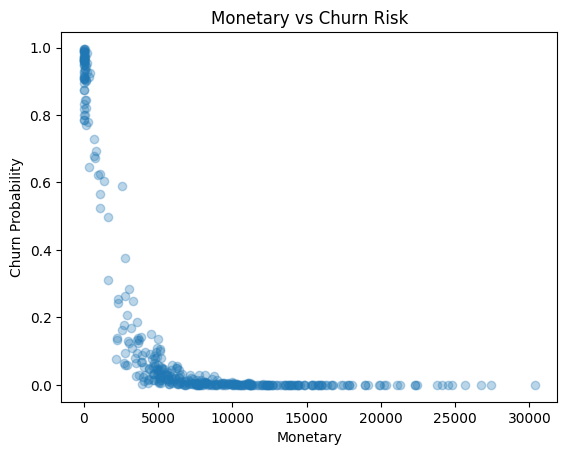

In [26]:
plt.figure()
plt.scatter(feat["monetary"], feat["churn_prob"], alpha=0.3)
plt.xlabel("Monetary")
plt.ylabel("Churn Probability")
plt.title("Monetary vs Churn Risk")
plt.show()